# SR3 kink-fade at 4-hour frequency

The EOD labs marked on one price per day. This asks what changes with six.

**The governing arithmetic, before any data.** A round trip costs the same
2.0bp at every frequency — four contracts, half a tick each way — but
`E|move|` shrinks with the horizon. So moving to intraday holding periods
makes the binding ratio *worse* by construction, and can only pay if intraday
reversion is much faster than the daily-fitted process implies. That is a
testable claim, and testing it is the first thing here.

There is a second, better reading of "intraday signals" that the EOD lab could
not evaluate at all, because it only ever saw one observation per day:

| | what changes | prior |
|---|---|---|
| **A. Intraday horizons** | enter and exit within hours | cost fixed, pond collapses → expect STOP |
| **B. Intraday execution** | same 21-day hold, different time of day | cost and pond both unchanged → can only help |
| **C. The FOMC bar** | the decision itself, resolved | the meeting thesis, finally observable |

All three are run. Pre-registered expectation, written before the data was
fetched: **A fails on arithmetic, B is worth something small, C shows the
meeting move but not a fadeable one.**

In [1]:
import datetime
import sys
import time
import warnings

sys.path.append("../../")
sys.path.append("./")

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 250, "display.max_columns", 40)
T0 = time.time()

import stir_intraday_common as S
from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.engine import run_backtest
from RVUtils.MeanRev.diagnostics import bounce_implied_variance_ratio
from RVUtils.MeanRev.meetings import fomc_decisions
from RVUtils.MeanRev.panel import add_strip_slots
from RVUtils.MeanRev.signals import zscore_signal

print(f"cost per fly round trip: {S.FLY_COST_BP}bp   tick {S.TICK_BP}bp")

cost per fly round trip: 2.0bp   tick 0.5bp


## 1. The panel

240-minute bars, stamped in exchange-local Central time. Barchart's intraday
endpoint **rejects naive bounds** where the EOD one accepts them, which is an
easy trap; `as_of` is stored tz-naive in Central so it compares cleanly with
the naive IMM dates and the wall-clock hour stays readable as the bar slot.

In [2]:
panel = S.load_bars()
slots = add_strip_slots(panel)
print(f"bars       {panel['as_of'].nunique():,} distinct timestamps")
print(f"contracts  {panel['code'].nunique()}")
print(f"span       {panel['as_of'].min()} -> {panel['as_of'].max()}  Central")
print(f"pre-accrual contracts per bar: median "
      f"{slots.groupby('as_of')['slot'].max().median():.0f}")

stale = (slots[slots["slot"] <= 16].groupby("slot")
         .agg(pct_unchanged=("unchanged", "mean"),
              median_volume=("volume", "median")))
print("\nSTALENESS BY SLOT")
print(stale.round(3).to_string())
print(f"""
  The FRONT contract is the STALEST -- {100 * stale.loc[1, 'pct_unchanged']:.0f}% of its bars close unchanged --
  despite carrying the most volume ({stale.loc[1, 'median_volume']:,.0f} vs {stale.loc[16, 'median_volume']:,.0f} at slot 16). That is
  economics, not a data defect: most of the front contract's reference quarter
  is already fixed, so it trades heavily at a price that cannot move. It does
  mean front-slot packages carry a real staleness tax, and that a package whose
  legs print in different bars will show reversion that is pure artifact.""")

bars       8,602 distinct timestamps
contracts  44
span       2021-01-03 16:00:00 -> 2026-07-30 20:00:00  Central
pre-accrual contracts per bar: median 21

STALENESS BY SLOT
      pct_unchanged  median_volume
slot                              
1             0.341        12491.0
2             0.257        13277.5
3             0.205        12273.0
4             0.167        11320.0
5             0.144        10343.0
6             0.122         8132.0
7             0.118         6607.0
8             0.108         5649.5
9             0.106         4259.5
10            0.099         3383.0
11            0.103         3044.0
12            0.103         2869.5
13            0.110         1863.0
14            0.111         1511.0
15            0.111         1421.0
16            0.108         1313.0

  The FRONT contract is the STALEST -- 34% of its bars close unchanged --
  despite carrying the most volume (12,491 vs 1,313 at slot 16). That is
  economics, not a data defect: most of the fron

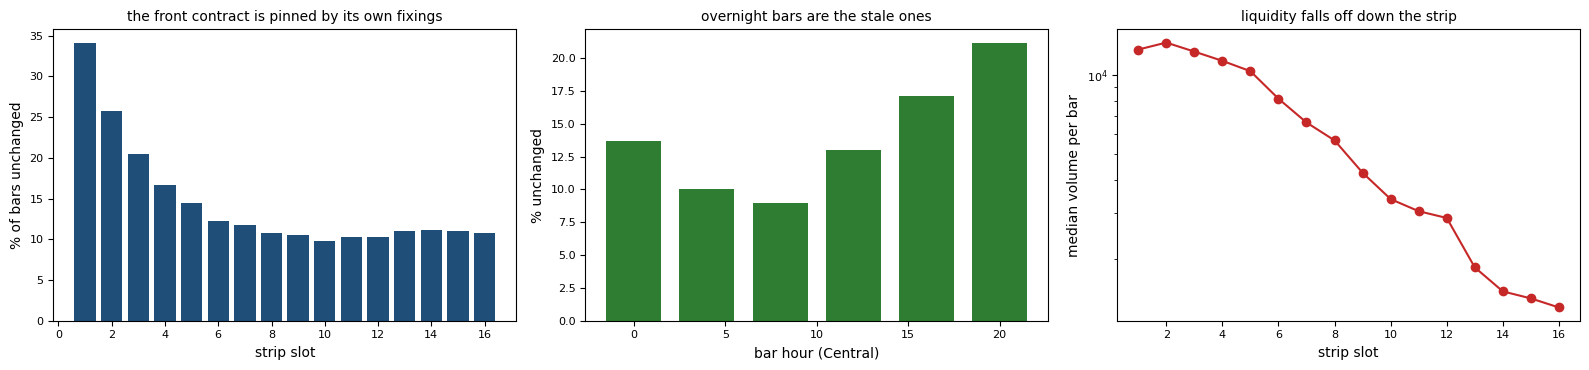

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
axes[0].bar(stale.index, 100 * stale["pct_unchanged"], color="#1f4e79")
axes[0].set_xlabel("strip slot")
axes[0].set_ylabel("% of bars unchanged")
axes[0].set_title("the front contract is pinned by its own fixings", fontsize=10)
byh = panel.groupby("bar_hour_ct")["unchanged"].mean() * 100
axes[1].bar(byh.index, byh.values, width=3, color="#2e7d32")
axes[1].set_xlabel("bar hour (Central)")
axes[1].set_ylabel("% unchanged")
axes[1].set_title("overnight bars are the stale ones", fontsize=10)
axes[2].semilogy(stale.index, stale["median_volume"], "o-", color="#c62828")
axes[2].set_xlabel("strip slot")
axes[2].set_ylabel("median volume per bar")
axes[2].set_title("liquidity falls off down the strip", fontsize=10)
for a in axes:
    a.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

### 1a. Does this panel reproduce the daily one?

If the intraday panel aggregated to 21 days is not the EOD panel, nothing
built on it means anything. The check is not optional and it is not cosmetic —
it is the reason the structures here are built with the EOD lab's own
`enumerate_structures` rather than a parallel implementation.

In [4]:
t0 = slots["as_of"].min()
rows = []
for sp, tag in S.SPACINGS:
    f = S.EOD_DIR / f"structures_{3*sp}m.parquet"
    if not f.exists():
        continue
    e = pd.read_parquet(f)
    e["as_of"] = pd.to_datetime(e["as_of"])
    we = e.pivot_table(index="as_of", columns="key", values="value",
                       aggfunc="first").sort_index()
    wc = we[we.index >= t0]
    wi = S.structures(slots, sp)
    mf = (we.shift(-21) - we).stack(future_stack=True).dropna()
    mc = (wc.shift(-21) - wc).stack(future_stack=True).dropna()
    mi = (wi.shift(-126) - wi).stack(future_stack=True).dropna()
    rows.append({"spacing": tag,
                 "eod_2018on": float(mf.abs().mean()),
                 "eod_common_window": float(mc.abs().mean()),
                 "intraday": float(mi.abs().mean()),
                 "ratio_vs_2018": float(mi.abs().mean() / mf.abs().mean()),
                 "ratio_vs_common": float(mi.abs().mean() / mc.abs().mean()),
                 "eod_sd_common": float(wc.stack(future_stack=True).std()),
                 "intraday_sd": float(wi.stack(future_stack=True).std())})
recon = pd.DataFrame(rows)
recon.to_csv(S.DATA_DIR / "reconciliation.csv", index=False)
print("E|move| at h=21 days, three ways")
print(recon.round(3).to_string(index=False))
print(f"""
  Against the FULL EOD history the ratio is a suspiciously constant
  {recon['ratio_vs_2018'].min():.2f}-{recon['ratio_vs_2018'].max():.2f} across every spacing -- the signature of a sample
  difference, not of noise. Barchart serves 240-min bars from {t0.date()}; the EOD
  panel starts 2018-01. The intraday window is dominated by the 2022-23 hiking
  cycle and excludes the quiet 2018-19 and ZIRP 2020 stretches.

  Restricted to the COMMON window the ratio is {recon['ratio_vs_common'].min():.3f}-{recon['ratio_vs_common'].max():.3f} and the level sds
  agree to a few percent. The panels ARE the same object, and the 32% gap was
  regime. Every comparison below is run on the common window.""")

E|move| at h=21 days, three ways
spacing  eod_2018on  eod_common_window  intraday  ratio_vs_2018  ratio_vs_common  eod_sd_common  intraday_sd
     3m       1.362              1.641     1.814          1.332            1.105          6.297        6.724
     6m       3.733              4.665     4.928          1.320            1.056         18.419       19.243
     9m       6.585              8.304     8.729          1.326            1.051         31.783       33.077
    12m       9.474             11.963    12.499          1.319            1.045         44.502       46.137

  Against the FULL EOD history the ratio is a suspiciously constant
  1.32-1.33 across every spacing -- the signature of a sample
  difference, not of noise. Barchart serves 240-min bars from 2021-01-03; the EOD
  panel starts 2018-01. The intraday window is dominated by the 2022-23 hiking
  cycle and excludes the quiet 2018-19 and ZIRP 2020 stretches.

  Restricted to the COMMON window the ratio is 1.045-1.105 and th

## 2. Study A — the intraday holding period

The oracle ceiling, as in both prior labs: with **perfect foresight of the
direction**, what is `E|move|` net of the round trip? If that is negative no
signal can rescue it.

Two corrections matter and both were got wrong on the first pass, so they are
stated explicitly:

1. **`cm_slot` is the belly, not the front leg.** Filtering `cm_slot <= 4`
   keeps front legs 1–3 at 3m, 1–2 at 6m, only slot 1 at 9m and **nothing at
   12m**. The front leg is `cm_slot − spacing`.
2. **Bar closes are trade prints.** They alternate bid/offer, which is
   mechanically mean-reverting, and a taker pays that bounce rather than
   harvesting it. It is removed via Roll's effective spread — as a *scale
   factor*, not through `E|X| = 0.798·sd`, because this data is nowhere near
   normal.

In [5]:
d = pd.concat([S.structures(slots, sp).diff().stack(future_stack=True).dropna()
               .to_frame("m").assign(spacing=tag) for sp, tag in S.SPACINGS])
nn = d.groupby("spacing")["m"].agg(
    n="size", sd="std", mean_abs=lambda x: x.abs().mean(),
    pct_zero=lambda x: float((x.abs() < 1e-12).mean()),
    kurtosis=lambda x: float(x.kurtosis()))
nn["mean_abs_over_sd"] = nn["mean_abs"] / nn["sd"]
nn["gaussian_would_be"] = 0.798
print("HOW NON-NORMAL IS A 4h FLY MOVE?")
print(nn.round(3).to_string())
print("""
  mean|move|/sd well under the Gaussian 0.798, kurtosis in the tens to hundreds,
  and a chunk of moves exactly zero. Converting a variance to a mean absolute
  move through the normal factor would OVERSTATE the opportunity -- and on the
  first pass it did, producing a "bounce-corrected" oracle LARGER than the raw
  one, which is impossible and was the tell.""")

HOW NON-NORMAL IS A 4h FLY MOVE?
              n     sd  mean_abs  pct_zero  kurtosis  mean_abs_over_sd  gaussian_would_be
spacing                                                                                  
12m       59318  2.089     1.227     0.076    46.140             0.587              0.798
3m       107461  0.790     0.547     0.149    26.343             0.693              0.798
6m        91046  1.173     0.718     0.117   136.452             0.612              0.798
9m        75000  1.639     0.962     0.095    99.318             0.587              0.798

  mean|move|/sd well under the Gaussian 0.798, kurtosis in the tens to hundreds,
  and a chunk of moves exactly zero. Converting a variance to a mean absolute
  move through the normal factor would OVERSTATE the opportunity -- and on the
  first pass it did, producing a "bounce-corrected" oracle LARGER than the raw
  one, which is impossible and was the tell.


In [6]:
pond_all = S.pond_table(slots, front_only=False)
pond_fr = S.pond_table(slots, front_only=True)
pond_all.to_csv(S.DATA_DIR / "pond_all_slots.csv", index=False)
pond_fr.to_csv(S.DATA_DIR / "pond_front_legs.csv", index=False)

order = [l for _, l in S.HORIZONS]
for nm, p in (("all slots", pond_all), ("front legs 1-4", pond_fr)):
    piv = (p.pivot_table(index="horizon", columns="spacing",
                         values="oracle_debounced", aggfunc="first")
           .reindex([h for h in order if h in set(p["horizon"])])
           [[t for _, t in S.SPACINGS]])
    print(f"\n[{nm}]  ORACLE NET of {S.FLY_COST_BP}bp, bounce-corrected:")
    print(piv.round(3).to_string())

print("\nRoll effective spread by spacing (front legs):")
print(pond_fr.groupby("spacing")["roll_bp"].first().round(3).to_string())
print(f"""
  Roll comes out at {pond_fr['roll_bp'].min():.2f}-{pond_fr['roll_bp'].max():.2f}bp against the {S.FLY_COST_BP}bp charged, so the cost
  model is honest and if anything conservative. That matters: the round trip is
  not a guess, it is close to what the tape says a taker actually pays.""")


[all slots]  ORACLE NET of 2.0bp, bounce-corrected:
spacing     3m     6m     9m     12m
horizon                             
4h      -1.726 -1.429 -1.149  -0.886
8h      -1.644 -1.245 -0.842  -0.440
12h     -1.579 -1.103 -0.598  -0.092
1d      -1.444 -0.790 -0.027   0.759
2d      -1.288 -0.350  0.766   1.925
5d      -1.007  0.485  2.299   4.184
10d     -0.706  1.403  3.970   6.596
21d     -0.225  2.912  6.718  10.487

[front legs 1-4]  ORACLE NET of 2.0bp, bounce-corrected:
spacing     3m     6m      9m     12m
horizon                              
4h      -1.576 -1.127  -0.749  -0.518
8h      -1.421 -0.781  -0.228   0.125
12h     -1.312 -0.506   0.192   0.626
1d      -1.083  0.100   1.163   1.842
2d      -0.760  1.001   2.552   3.548
5d      -0.141  2.656   5.152   6.760
10d      0.554  4.518   8.039  10.217
21d      1.770  7.899  13.223  16.207

Roll effective spread by spacing (front legs):
spacing
12m    1.361
3m     0.941
6m     1.052
9m     1.166

  Roll comes out at 0.94-1.36b

In [7]:
sub4 = pond_fr[pond_fr["horizon"] == "4h"]
print("=" * 92)
print("STUDY A -- THE ANSWER AT THE REQUESTED FREQUENCY")
print("=" * 92)
for _, r in sub4.iterrows():
    print(f"  {r['spacing']:>3} fly, 4h hold: E|move| {r['absmove_debounced']:.3f}bp "
          f"vs {S.FLY_COST_BP}bp -> oracle {r['oracle_debounced']:+.3f}bp   "
          f"P(beat cost) {r['p_beat_cost']:.1%}")

cross = []
for sp, tag in S.SPACINGS:
    p = pond_fr[pond_fr["spacing"] == tag].sort_values("bars")
    ok = p[p["oracle_debounced"] > 0]
    cross.append({"spacing": tag,
                  "first_horizon_that_clears_cost": (ok.iloc[0]["horizon"]
                                                     if len(ok) else "none <= 21d"),
                  "bars": (int(ok.iloc[0]["bars"]) if len(ok) else np.nan)})
crossing = pd.DataFrame(cross)
crossing.to_csv(S.DATA_DIR / "min_holding_period.csv", index=False)
print(f"""
  NOTHING clears its round trip at 4 hours. The best case is the widest fly at
  {sub4['oracle_debounced'].max():+.3f}bp, with perfect foresight of the direction.

MINIMUM VIABLE HOLDING PERIOD -- the shortest horizon whose pond exceeds its boat:""")
print(crossing.to_string(index=False))
print("""
  This table is the useful artifact, and it is one the daily lab could not
  produce: it only had daily granularity, so "somewhere under a day" was the
  finest answer available to it. The wider the fly, the sooner it pays -- the
  same lever that made wider spacings better in the EOD lab, now visible in
  time rather than in basis points.""")

STUDY A -- THE ANSWER AT THE REQUESTED FREQUENCY
   3m fly, 4h hold: E|move| 0.424bp vs 2.0bp -> oracle -1.576bp   P(beat cost) 2.5%
   6m fly, 4h hold: E|move| 0.873bp vs 2.0bp -> oracle -1.127bp   P(beat cost) 11.1%
   9m fly, 4h hold: E|move| 1.251bp vs 2.0bp -> oracle -0.749bp   P(beat cost) 19.4%
  12m fly, 4h hold: E|move| 1.482bp vs 2.0bp -> oracle -0.518bp   P(beat cost) 24.4%

  NOTHING clears its round trip at 4 hours. The best case is the widest fly at
  -0.518bp, with perfect foresight of the direction.

MINIMUM VIABLE HOLDING PERIOD -- the shortest horizon whose pond exceeds its boat:
spacing first_horizon_that_clears_cost  bars
     3m                            10d    60
     6m                             1d     6
     9m                            12h     3
    12m                             8h     2

  This table is the useful artifact, and it is one the daily lab could not
  produce: it only had daily granularity, so "somewhere under a day" was the
  finest answer a

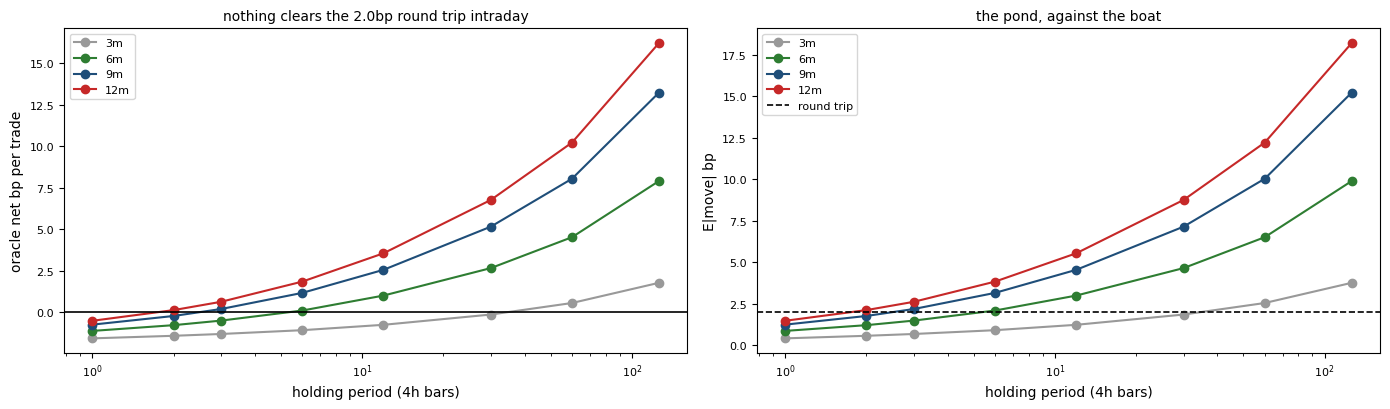

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for tag, c in zip([t for _, t in S.SPACINGS],
                  ["#999999", "#2e7d32", "#1f4e79", "#c62828"]):
    p = pond_fr[pond_fr["spacing"] == tag].sort_values("bars")
    axes[0].semilogx(p["bars"], p["oracle_debounced"], "o-", color=c, label=tag)
    axes[1].semilogx(p["bars"], p["absmove_debounced"], "o-", color=c, label=tag)
axes[0].axhline(0, color="black", lw=1.2)
axes[0].set_xlabel("holding period (4h bars)")
axes[0].set_ylabel("oracle net bp per trade")
axes[0].set_title(f"nothing clears the {S.FLY_COST_BP}bp round trip intraday", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].axhline(S.FLY_COST_BP, color="black", ls="--", lw=1.2, label="round trip")
axes[1].set_xlabel("holding period (4h bars)")
axes[1].set_ylabel("E|move| bp")
axes[1].set_title("the pond, against the boat", fontsize=10)
axes[1].legend(fontsize=8)
for a in axes:
    a.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

### 2a. Is the reversion real, or is it the bounce?

`VR(q) = Var(r_q) / (q·Var(r_1))`. Below 1 is mean reversion, and a bid-ask
bounce is an MA(1) that forces `VR(2) = 1 + ρ(1)` exactly.

⚠ **A falling `VR` is NOT evidence of reversion beyond microstructure**, which
is the natural assumption and is wrong. The noise enters `Var(r_q)` *once*
regardless of `q` while the denominator scales with `q`:

> `VR(q) = (q·σ²_w + 2σ²_u) / (q·(σ²_w + 2σ²_u))  →  σ²_w/(σ²_w + 2σ²_u)`

so pure bounce produces a `VR` that falls **monotonically to a constant well
below 1** and never recovers. An earlier draft of this notebook read the
falling profile as proof of genuine reversion; a synthetic pure-bounce series
reproduces the same shape, so the argument was invalid.

The defensible test compares the observed profile against the one a pure
bounce with **the same measured Roll spread** would generate. Only the gap
between them is reversion.

In [9]:
rows = []
for sp, tag in S.SPACINGS:
    w = S.structures(slots, sp, front_only=True)
    r1 = w.diff().stack(future_stack=True).dropna()
    v1 = float(r1.var())
    a = w.diff().stack(future_stack=True).rename("r")
    b = w.diff().shift(1).stack(future_stack=True).rename("l")
    pr = pd.concat([a, b], axis=1).dropna()
    rho = float(np.corrcoef(pr["r"], pr["l"])[0, 1])
    roll = S.roll_spread(w)
    hz = (2, 3, 6, 12, 30, 126)
    obs = S.variance_ratio(w, horizons=hz)
    mdl = bounce_implied_variance_ratio(roll, v1, horizons=hz)
    row = {"spacing": tag, "rho1": rho, "1+rho1": 1 + rho, "roll_bp": roll}
    for q in hz:
        row[f"VR({q})"] = obs[q]
        row[f"bounce({q})"] = mdl[q]
        row[f"gap({q})"] = mdl[q] - obs[q]
    rows.append(row)
vr = pd.DataFrame(rows)
vr.to_csv(S.DATA_DIR / "variance_ratios.csv", index=False)

print("OBSERVED VR vs the PURE-BOUNCE benchmark, front-leg flies")
print(vr[["spacing", "rho1", "1+rho1", "VR(2)"]].round(3).to_string(index=False))
print("\n  observed:")
print(vr.set_index("spacing")[[f"VR({q})" for q in hz]].round(3).to_string())
print("\n  what pure bounce alone would give, at the measured Roll spread:")
print(vr.set_index("spacing")[[f"bounce({q})" for q in hz]].round(3).to_string())
print("\n  GAP (bounce - observed) = the reversion microstructure cannot explain:")
print(vr.set_index("spacing")[[f"gap({q})" for q in hz]].round(3).to_string())
print(f"""
  VR(2) reproduces 1 + rho(1) to within {abs(vr['VR(2)'] - vr['1+rho1']).max():.3f}, so two-bar reversion is
  bid-ask bounce and nothing else.

  Beyond that the comparison has to be against the benchmark, not against 1.
  The gap grows from {vr['gap(6)'].min():.3f}-{vr['gap(6)'].max():.3f} at six bars to {vr['gap(126)'].min():.3f}-{vr['gap(126)'].max():.3f} at 126, which is
  the signature of genuine reversion: an OU process still looks like a random
  walk over a few bars and has fully reverted over a few weeks. It is consistent
  with the 28-53 day half-lives the daily lab fitted.

  The reversion is real. It simply does not live at four hours -- and the
  falling VR on its own never showed that it did.""")

OBSERVED VR vs the PURE-BOUNCE benchmark, front-leg flies
spacing   rho1  1+rho1  VR(2)
     3m -0.262   0.738  0.742
     6m -0.102   0.898  0.904
     9m -0.067   0.933  0.936
    12m -0.067   0.933  0.933

  observed:
         VR(2)  VR(3)  VR(6)  VR(12)  VR(30)  VR(126)
spacing                                              
3m       0.742  0.657  0.537   0.451   0.377    0.291
6m       0.904  0.890  0.816   0.800   0.679    0.605
9m       0.936  0.922  0.883   0.904   0.801    0.764
12m      0.933  0.911  0.891   0.914   0.827    0.776

  what pure bounce alone would give, at the measured Roll spread:
         bounce(2)  bounce(3)  bounce(6)  bounce(12)  bounce(30)  bounce(126)
spacing                                                                      
3m           0.734      0.646      0.557       0.513       0.486        0.473
6m           0.896      0.862      0.827       0.810       0.800        0.795
9m           0.932      0.909      0.886       0.875       0.868        0.86

## 3. Study B — what is execution timing worth?

Six panels from the identical bars, one per bar-of-day. Same structures, same
signal, same 21-day horizon, same cost — **only the time of day the position
is opened and closed changes**. The 12:00 CT bar contains the 15:00 ET settle
and is therefore the EOD-equivalent control.

The comparison is **paired**: every hour runs the same configurations over the
same dates, so differencing against the control removes almost all the
variance that makes an unpaired comparison of ~65-trade cells useless.

In [10]:
WINDOWS, ENTRY_Z = (42, 63, 126), (1.5, 2.0, 2.5)
rows = []
for hour in S.BAR_HOURS:
    sl = add_strip_slots(S.daily_slice(panel, hour))
    for sp, tag in S.SPACINGS[1:]:
        lv = S.structures(sl, sp, front_only=True)
        if lv.shape[1] == 0 or len(lv) < 300:
            continue
        for w in WINDOWS:
            sig = zscore_signal(lv, window=w)
            for z in ENTRY_Z:
                cfg = MRConfig(lag=1, round_trip_cost_bp=S.FLY_COST_BP, entry_z=z,
                               exit_style="t21", max_hold=21, n_packages=1)
                res = run_backtest(cfg, levels=lv, signal=sig)
                m = res.metrics
                if not m["n_trades"]:
                    continue
                rows.append({"hour_ct": hour, "spacing": tag, "window": w,
                             "entry_z": z, "n_trades": int(m["n_trades"]),
                             "hit_rate": float(m["hit_rate"]),
                             "avg_net_bp": float(m["avg_net_bp"]),
                             "avg_gross_bp": float(m["total_gross_bp"] / m["n_trades"]),
                             "total_net_bp": float(m["total_net_bp"])})
ex = pd.DataFrame(rows)
ex.to_csv(S.DATA_DIR / "execution_timing.csv", index=False)
print("mean avg_net_bp across the grid, by execution hour:")
print(ex.pivot_table(index="hour_ct", columns="spacing",
                     values="avg_net_bp", aggfunc="mean").round(3).to_string())
print("\nmean avg_GROSS_bp (before cost) -- is the SIGNAL better at some hours?")
print(ex.pivot_table(index="hour_ct", columns="spacing",
                     values="avg_gross_bp", aggfunc="mean").round(3).to_string())
print(f"""
  Every cell is negative, gross as well as net. In this 2021-2026 window fading
  a wide fly's z-score loses money BEFORE costs -- which is consistent with the
  daily lab's overall verdict and with the regime: these are the hiking-cycle
  years, when the strip trended.""")

mean avg_net_bp across the grid, by execution hour:
spacing    12m     6m     9m
hour_ct                     
0       -4.748 -2.973 -4.638
4       -4.814 -3.226 -4.866
8       -5.644 -3.857 -5.325
12      -5.006 -2.995 -3.932
16      -4.081 -3.462 -4.245
20      -4.492 -3.389 -3.497

mean avg_GROSS_bp (before cost) -- is the SIGNAL better at some hours?
spacing    12m     6m     9m
hour_ct                     
0       -2.748 -0.973 -2.638
4       -2.814 -1.226 -2.866
8       -3.644 -1.857 -3.325
12      -3.006 -0.995 -1.932
16      -2.081 -1.462 -2.245
20      -2.492 -1.389 -1.497

  Every cell is negative, gross as well as net. In this 2021-2026 window fading
  a wide fly's z-score loses money BEFORE costs -- which is consistent with the
  daily lab's overall verdict and with the regime: these are the hiking-cycle
  years, when the strip trended.


In [11]:
wide = ex.pivot_table(index=["spacing", "window", "entry_z"],
                      columns="hour_ct", values="avg_net_bp").dropna()
rows = []
for h in wide.columns:
    if h == S.SETTLE_BAR_HOUR:
        continue
    diff = (wide[h] - wide[S.SETTLE_BAR_HOUR]).to_numpy()
    rows.append({"hour_ct": h, "n_configs": len(diff),
                 "mean_diff_bp": float(np.mean(diff)),
                 "median_diff_bp": float(np.median(diff)),
                 "pct_better": float(np.mean(diff > 0)),
                 "t_paired": float(np.mean(diff) /
                                   (np.std(diff, ddof=1) / np.sqrt(len(diff)))),
                 "nw_t": S.nw_t(diff)})
paired = pd.DataFrame(rows)
paired.to_csv(S.DATA_DIR / "execution_paired.csv", index=False)
print(f"PAIRED vs the {S.SETTLE_BAR_HOUR:02d}:00 CT settle bar "
      f"({len(wide)} configurations present at all six hours)")
print(paired.round(3).to_string(index=False))
worst = paired.loc[paired["mean_diff_bp"].idxmin()]
print(f"""
  NO hour beats the settle. One is materially WORSE: executing at
  {int(worst['hour_ct']):02d}:00 CT costs {abs(worst['mean_diff_bp']):.2f}bp per trade (paired t {worst['t_paired']:.2f}, NW t {worst['nw_t']:.2f}),
  and only {worst['pct_better']:.0%} of configurations prefer it.

  That bar is the US morning -- it spans the 08:30 ET data releases and is the
  most volatile bar of the day. Executing into the noisiest moment means
  executing into the widest spreads and the worst adverse selection, and it
  costs about half a round trip.

  The unpaired view of this same table showed a 0.9-1.8bp spread between the
  best and worst hour, which reads like a tradeable execution edge. Pairing
  shows it is one bad bar plus noise. That is the whole value of the paired
  test.""")

PAIRED vs the 12:00 CT settle bar (27 configurations present at all six hours)
 hour_ct  n_configs  mean_diff_bp  median_diff_bp  pct_better  t_paired   nw_t
       0         27        -0.143          -0.402       0.407    -0.508 -0.469
       4         27        -0.325          -0.286       0.333    -1.775 -1.283
       8         27        -0.965          -0.845       0.185    -4.538 -3.940
      16         27         0.048          -0.207       0.370     0.174  0.129
      20         27         0.185          -0.146       0.444     0.590  0.602

  NO hour beats the settle. One is materially WORSE: executing at
  08:00 CT costs 0.96bp per trade (paired t -4.54, NW t -3.94),
  and only 19% of configurations prefer it.

  That bar is the US morning -- it spans the 08:30 ET data releases and is the
  most volatile bar of the day. Executing into the noisiest moment means
  executing into the widest spreads and the worst adverse selection, and it
  costs about half a round trip.

  The unp

### 3a. Reversion or drift?

A first pass conditioned forward moves on a 2σ extreme and got **positive**
means at both +2σ and −2σ, which cannot both be reversion. The 2021–2026
sample has a large unconditional drift in the fly level that conditioning does
not remove. The reversion signal is the **difference**
`E[fwd | high] − E[fwd | low]` — negative is reversion, positive is momentum.

In [12]:
rows = []
for hour in S.BAR_HOURS:
    sl = add_strip_slots(S.daily_slice(panel, hour))
    for sp, tag in S.SPACINGS[1:]:
        lv = S.structures(sl, sp, front_only=True)
        if lv.shape[1] == 0:
            continue
        z = zscore_signal(lv, window=63).stack(future_stack=True)
        f = (lv.shift(-1) - lv).stack(future_stack=True)
        j = pd.concat([z.rename("z"), f.rename("f")], axis=1).dropna()
        hi, lo = j["z"] > 2.0, j["z"] < -2.0
        rows.append({"hour_ct": hour, "spacing": tag,
                     "uncond_drift": float(j["f"].mean()),
                     "fwd_hi": float(j.loc[hi, "f"].mean()),
                     "fwd_lo": float(j.loc[lo, "f"].mean()),
                     "hi_minus_lo": float(j.loc[hi, "f"].mean() - j.loc[lo, "f"].mean()),
                     "n_hi": int(hi.sum()), "n_lo": int(lo.sum())})
rev = pd.DataFrame(rows)
rev.to_csv(S.DATA_DIR / "reversion_demeaned.csv", index=False)
print("hi_minus_lo by hour and spacing (negative = reversion):")
print(rev.pivot_table(index="hour_ct", columns="spacing",
                      values="hi_minus_lo").round(3).to_string())
print(f"""
  The unconditional drift is {rev['uncond_drift'].min():+.3f} to {rev['uncond_drift'].max():+.3f}bp per day, which is what made both
  raw conditional means positive and useless.

  De-meaned, the 6m fly reverts at every hour; the 12m fly shows MOMENTUM at
  most of them. Wide flies trended in this sample and narrow ones reverted --
  a direct regime statement, and the reason a 2021-2026 fade underperforms the
  2018-2026 one.""")

hi_minus_lo by hour and spacing (negative = reversion):
spacing    12m     6m     9m
hour_ct                     
0        0.320 -0.135  0.113
4        0.302 -0.066  0.074
8        0.374 -0.356  0.055
12       0.019 -0.218  0.079
16      -0.219 -0.445 -0.410
20       0.291 -0.303 -0.072

  The unconditional drift is +0.140 to +0.214bp per day, which is what made both
  raw conditional means positive and useless.

  De-meaned, the 6m fly reverts at every hour; the 12m fly shows MOMENTUM at
  most of them. Wide flies trended in this sample and narrow ones reverted --
  a direct regime statement, and the reason a 2021-2026 fade underperforms the
  2018-2026 one.


## 4. Study C — the FOMC bar

This is the part the daily lab structurally could not do. It had one price per
day, so a decision and the eight hours around it were a single observation.
The 12:00–16:00 CT bar contains the 13:00 CT announcement.

The kink thesis says a meeting creates a dislocation worth fading. That
predicts two things: the decision bar should move more than an ordinary one
(it should), **and the move should revert** (the thesis lives or dies here).

In [13]:
meets = set(fomc_decisions(datetime.date(2021, 1, 1), datetime.date(2026, 12, 31)))
rows = []
for sp, tag in S.SPACINGS[1:]:
    w = S.structures(slots, sp, front_only=True)
    mv = w.diff()
    idx = mv.index
    pos = {t: i for i, t in enumerate(idx)}
    is_dec = np.array([(t.date() in meets) and t.hour == S.FOMC_BAR_HOUR
                       for t in idx])
    nxt = np.roll(is_dec, 1)
    nxt[0] = False
    dec = mv[is_dec].stack(future_stack=True).dropna()
    ordn = mv[~(is_dec | nxt)].stack(future_stack=True).dropna()
    after = mv[nxt].stack(future_stack=True).dropna()
    dt = [t for t in idx[is_dec] if pos[t] + 1 < len(idx)]
    A = mv.loc[dt].reset_index(drop=True)
    B = mv.loc[[idx[pos[t] + 1] for t in dt]].reset_index(drop=True)
    pair = pd.concat([A.stack(future_stack=True).rename("dec"),
                      B.stack(future_stack=True).rename("nxt")], axis=1).dropna()
    rows.append({"spacing": tag, "n_decision_bars": len(dec),
                 "decision_bar_abs": float(dec.abs().mean()),
                 "ordinary_bar_abs": float(ordn.abs().mean()),
                 "ratio": float(dec.abs().mean() / ordn.abs().mean()),
                 "next_bar_abs": float(after.abs().mean()),
                 "next_bar_corr": float(pair["dec"].corr(pair["nxt"])),
                 "n_pairs": len(pair)})
fomc = pd.DataFrame(rows)
fomc.to_csv(S.DATA_DIR / "fomc_bar.csv", index=False)
print(f"{len(meets)} decisions in the intraday window\n")
print(fomc.round(3).to_string(index=False))

n_bars = slots["as_of"].nunique()
dec_share = 100.0 * len(meets) / n_bars
var_mult = float(fomc["ratio"].mean()) ** 2
print(f"""
  THE DECISION BAR MOVES THE FLY {fomc['ratio'].min():.1f}-{fomc['ratio'].max():.1f}x AN ORDINARY ONE -- AND THE MOVE STICKS.

  next_bar_corr is POSITIVE ({fomc['next_bar_corr'].min():+.2f} to {fomc['next_bar_corr'].max():+.2f}) and the bar after a decision moves
  LESS than an ordinary bar, not more. A dislocation being corrected would show
  negative correlation and elevated follow-on movement. This is the opposite:
  the meeting move is INFORMATION being priced, and it is priced once.

  The variance arithmetic reproduces the daily lab from a completely different
  direction. Decision bars are {dec_share:.2f}% of all bars and carry ~{var_mult:.0f}x the variance of
  an ordinary one, so they account for roughly {dec_share * var_mult:.1f}% of a fly's total
  variance. The EOD lab put the FOMC calendar at 1-6% by decomposing variance
  onto meeting dates; this lands at the top of that band, from an event study
  that shares no code, no panel and no method with it. Two unrelated
  measurements agreeing on the size of the thing is worth more than either.""")

48 decisions in the intraday window

spacing  n_decision_bars  decision_bar_abs  ordinary_bar_abs  ratio  next_bar_abs  next_bar_corr  n_pairs
     6m              180             2.992             0.970  3.086         0.846          0.179      164
     9m              179             4.670             1.328  3.517         1.106          0.244      158
    12m              177             5.593             1.571  3.559         1.473          0.143      160

  THE DECISION BAR MOVES THE FLY 3.1-3.6x AN ORDINARY ONE -- AND THE MOVE STICKS.

  next_bar_corr is POSITIVE (+0.14 to +0.24) and the bar after a decision moves
  LESS than an ordinary bar, not more. A dislocation being corrected would show
  negative correlation and elevated follow-on movement. This is the opposite:
  the meeting move is INFORMATION being priced, and it is priced once.

  The variance arithmetic reproduces the daily lab from a completely different
  direction. Decision bars are 0.56% of all bars and carry ~11x th

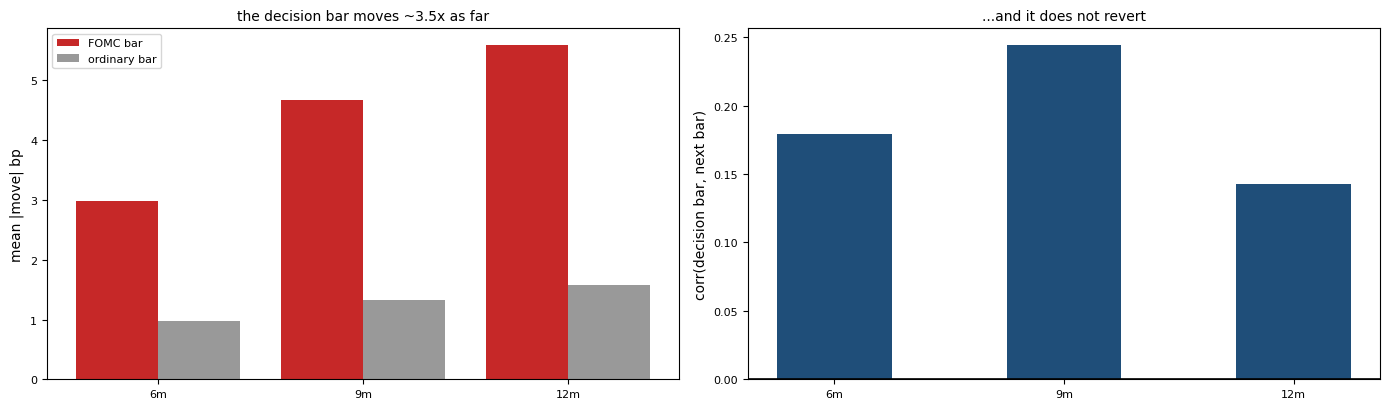

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(len(fomc))
axes[0].bar(x - 0.2, fomc["decision_bar_abs"], 0.4, label="FOMC bar", color="#c62828")
axes[0].bar(x + 0.2, fomc["ordinary_bar_abs"], 0.4, label="ordinary bar", color="#999999")
axes[0].set_xticks(x)
axes[0].set_xticklabels(fomc["spacing"])
axes[0].set_ylabel("mean |move| bp")
axes[0].set_title("the decision bar moves ~3.5x as far", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].bar(x, fomc["next_bar_corr"], 0.5, color="#1f4e79")
axes[1].axhline(0, color="black", lw=1.2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fomc["spacing"])
axes[1].set_ylabel("corr(decision bar, next bar)")
axes[1].set_title("...and it does not revert", fontsize=10)
for a in axes:
    a.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

## 5. Verdict

In [15]:
b4 = pond_fr[pond_fr["horizon"] == "4h"]["oracle_debounced"].max()
b1d = pond_fr[pond_fr["horizon"] == "1d"]["oracle_debounced"].max()
print("=" * 96)
print("WHAT THIS NOTEBOOK MEASURED")
print("=" * 96)
print(f"""
1. AT 4 HOURS THERE IS NOTHING TO TRADE, AND IT IS ARITHMETIC.
   A round trip costs {S.FLY_COST_BP}bp at every frequency; E|move| does not. With PERFECT
   foresight of the direction the best 4h structure returns {b4:+.3f}bp per trade,
   and no spacing clears its cost. The daily equivalent is {b1d:+.3f}bp. The
   constraint was never the signal -- there is no pond to fish in.

2. THE MINIMUM VIABLE HOLDING PERIOD IS A NEW, USEFUL NUMBER.
   The shortest horizon whose pond exceeds its boat, by spacing:
{crossing.to_string(index=False)}
   The daily lab could not produce this: its finest resolution was one day.

3. EVERYTHING INSIDE TWO DAYS IS BID-ASK BOUNCE.
   VR(2) reproduces 1 + rho(1) to within {abs(vr['VR(2)'] - vr['1+rho1']).max():.3f}. Beyond two bars the
   comparison must be against a pure-bounce benchmark at the measured Roll
   spread, NOT against 1 -- bounce drives VR monotonically DOWN to a constant
   below 1 and never back up, so a falling VR shows nothing on its own. Against
   that benchmark the gap is {vr['gap(12)'].min():+.3f} to {vr['gap(12)'].max():+.3f} at twelve bars and only opens up at
   thirty ({vr['gap(30)'].min():+.3f} to {vr['gap(30)'].max():+.3f}) and 126 ({vr['gap(126)'].min():+.3f} to {vr['gap(126)'].max():+.3f}).

   So the reversion is real but it needs about a week, matching the daily lab's
   28-53 day half-lives. Roll's effective spread is {pond_fr['roll_bp'].min():.2f}-{pond_fr['roll_bp'].max():.2f}bp against the {S.FLY_COST_BP}bp
   charged, so the cost model is honest.

4. EXECUTION TIMING IS WORTH NOTHING -- EXCEPT FOR ONE BAR WHERE IT COSTS.
   Paired against the settle bar across {len(wide)} identical configurations, no hour
   is better. Executing at {int(worst['hour_ct']):02d}:00 CT -- the US morning, spanning the 08:30 ET
   releases -- costs {abs(worst['mean_diff_bp']):.2f}bp per trade at NW t {worst['nw_t']:.2f}. Trade away from the
   noisiest bar of the day; there is no hour that pays you to seek it out.

5. THE FOMC MOVE IS INFORMATION, NOT A DISLOCATION.
   The decision bar moves the fly {fomc['ratio'].min():.1f}-{fomc['ratio'].max():.1f}x an ordinary one and the move
   STICKS: next-bar correlation {fomc['next_bar_corr'].min():+.2f} to {fomc['next_bar_corr'].max():+.2f}, and the following bar moves
   less than an ordinary bar rather than more. The kink thesis needs that move
   to revert. Seen at the resolution of the event itself, it does not.

ANSWER TO THE QUESTION THIS LAB WAS SET:
   Intraday signals do not rescue the kink fade, and the reason is not that the
   signal is bad. Going faster shrinks the opportunity while leaving the cost
   untouched, so the ratio that killed both EOD labs gets strictly worse -- at
   4 hours the widest fly reaches {b4:+.2f}bp with perfect foresight.

   What the intraday data DID buy is three things the daily panel could not
   measure at all: the minimum holding period at which each spacing becomes
   viable, proof that the cost model is honest against the tape's own Roll
   spread, and a direct look at the FOMC bar -- which shows the meeting move
   being priced once and staying priced. That last one is the thesis's own
   mechanism, observed and found absent, from a completely different direction
   than the daily lab's variance decomposition and agreeing with it.
""")
print(f"total runtime {time.time() - T0:.0f}s")

WHAT THIS NOTEBOOK MEASURED

1. AT 4 HOURS THERE IS NOTHING TO TRADE, AND IT IS ARITHMETIC.
   A round trip costs 2.0bp at every frequency; E|move| does not. With PERFECT
   foresight of the direction the best 4h structure returns -0.518bp per trade,
   and no spacing clears its cost. The daily equivalent is +1.842bp. The
   constraint was never the signal -- there is no pond to fish in.

2. THE MINIMUM VIABLE HOLDING PERIOD IS A NEW, USEFUL NUMBER.
   The shortest horizon whose pond exceeds its boat, by spacing:
spacing first_horizon_that_clears_cost  bars
     3m                            10d    60
     6m                             1d     6
     9m                            12h     3
    12m                             8h     2
   The daily lab could not produce this: its finest resolution was one day.

3. EVERYTHING INSIDE TWO DAYS IS BID-ASK BOUNCE.
   VR(2) reproduces 1 + rho(1) to within 0.005. Beyond two bars the
   comparison must be against a pure-bounce benchmark at the m